# A군 - PPI(양성자 펌프 억제제) 분석

## 파트 1. PPI 계열 비중 및 연령대/부작용 분석

In [1]:
!apt-get -qq install fonts-nanum > /dev/null
!fc-cache -fv > /dev/null
import pandas as pd
import numpy as np
import re
import math
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from scipy.stats import chi2_contingency, fisher_exact
import statsmodels.formula.api as smf

font_path = "/usr/share/fonts/truetype/nanum/NanumGothic.ttf"
fm.fontManager.addfont(font_path)
plt.rcParams["font.family"] = fm.FontProperties(fname=font_path).get_name()
plt.rcParams["axes.unicode_minus"] = False

RED_DARK, RED_MAIN, RED_MID, RED_LIGHT = "#7F0000", "#B22222", "#D95F5F", "#F4B6B6"

# 데이터 로드 및 A군 중 PPI 계열 필터링 (성분명/브랜드명/약효분류 기준)
file_path = "/content/FDA_adverse_events_final.csv"
df = pd.read_csv(file_path)
df["WHO_ATC"] = df["WHO_ATC"].astype(str).str.strip().str.upper()
df_a = df[df["WHO_ATC"] == "A"].copy()

ppi_map = {
    "Dexlansoprazole": ["dexlansoprazole", "dexilant"],
    "Esomeprazole": ["esomeprazole", "nexium"],
    "Lansoprazole": ["lansoprazole", "prevacid"],
    "Omeprazole": ["omeprazole", "prilosec", "zegerid", "losec"],
    "Pantoprazole": ["pantoprazole", "protonix"],
    "Rabeprazole": ["rabeprazole", "aciphex"]
}

def detect_ppi_ingredients(row):
    text = " ".join([str(row.get("suspect_drug", "")), str(row.get("brand_name", "")), str(row.get("pharm_class", ""))]).lower()
    detected = []
    for ingredient, terms in ppi_map.items():
        for term in terms:
            if re.search(r"\b" + re.escape(term) + r"\b", text):
                detected.append(ingredient)
                break
    return detected

df_a["ppi_list"] = df_a.apply(detect_ppi_ingredients, axis=1)
df_a["is_ppi"] = df_a["ppi_list"].apply(lambda x: len(x) > 0)

df_ppi = df_a[df_a["is_ppi"]].copy().reset_index(drop=True)
df_ppi["row_id"] = df_ppi.index
df_ppi["ppi_ingredient"] = df_ppi["ppi_list"].apply(lambda x: x[0])
df_ppi["serious_bool"] = df_ppi["serious"].astype(str).str.lower().eq("yes")

a_total = len(df_a)
ppi_count = df_a["is_ppi"].sum()
non_ppi_count = a_total - ppi_count

print("A군 전체 보고건 수:", a_total)
print("A군 중 PPI 보고건 수:", len(df_ppi))
print("A군 내 PPI 비율:", round(ppi_count / a_total * 100, 1), "%")

A군 전체 보고건 수: 9622
A군 중 PPI 보고건 수: 8879
A군 내 PPI 비율: 92.3 %


,category,count,percent
0,PPI 계열,8879,92.278113
1,비-PPI,743,7.721887


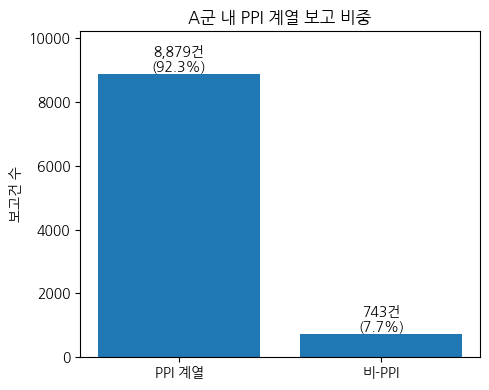

In [2]:
# A군 내 PPI 비중 - 막대그래프
ppi_summary = pd.DataFrame({"category": ["PPI 계열", "비-PPI"], "count": [ppi_count, non_ppi_count]})
ppi_summary["percent"] = ppi_summary["count"] / a_total * 100
display(ppi_summary)

plt.figure(figsize=(5, 4))
bars = plt.bar(ppi_summary["category"], ppi_summary["count"])
plt.title("A군 내 PPI 계열 보고 비중")
plt.ylabel("보고건 수")
plt.ylim(0, ppi_summary["count"].max() * 1.15)
for bar, pct in zip(bars, ppi_summary["percent"]):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height, f"{height:,}건\n({pct:.1f}%)", ha="center", va="bottom")
plt.tight_layout()
plt.show()

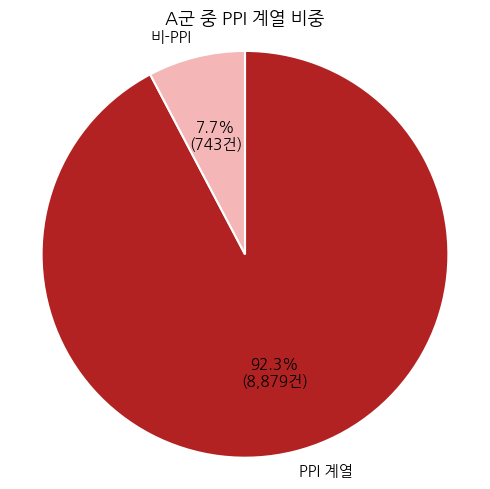

In [3]:
# A군 중 PPI 계열 비중 - 원그래프 (붉은 계열)
labels = ["PPI 계열", "비-PPI"]
counts = [ppi_count, non_ppi_count]
colors = ["#B22222", "#F4B6B6"]

def autopct_format(values):
    def my_format(pct):
        total = sum(values)
        count = int(round(pct * total / 100.0))
        return f"{pct:.1f}%\n({count:,}건)"
    return my_format

plt.figure(figsize=(5, 5))
plt.pie(counts, labels=labels, autopct=autopct_format(counts), startangle=90, counterclock=False,
        colors=colors, textprops={"fontsize": 11}, wedgeprops={"edgecolor": "white", "linewidth": 1.5})
plt.title("A군 중 PPI 계열 비중", fontsize=13, fontweight="bold")
plt.axis("equal")
plt.tight_layout()
plt.show()

,ppi_ingredient,count,percent
0,Esomeprazole,3238,36.468071
1,Lansoprazole,1975,22.243496
2,Omeprazole,1970,22.187183
3,Pantoprazole,1696,19.101250


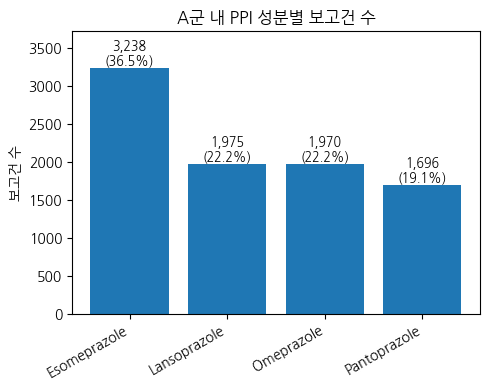

In [4]:
# PPI 성분별 보고건 수
ppi_ingredient_counts = df_a[df_a["is_ppi"]]["ppi_list"].explode().value_counts().reset_index()
ppi_ingredient_counts.columns = ["ppi_ingredient", "count"]
ppi_ingredient_counts["percent"] = ppi_ingredient_counts["count"] / ppi_ingredient_counts["count"].sum() * 100
display(ppi_ingredient_counts)

plt.figure(figsize=(5, 4))
bars = plt.bar(ppi_ingredient_counts["ppi_ingredient"], ppi_ingredient_counts["count"])
plt.title("A군 내 PPI 성분별 보고건 수")
plt.ylabel("보고건 수")
plt.xticks(rotation=30, ha="right")
plt.ylim(0, ppi_ingredient_counts["count"].max() * 1.15)
for bar, pct in zip(bars, ppi_ingredient_counts["percent"]):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height, f"{height:,}\n({pct:.1f}%)", ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.show()

,이상반응,보고건 수,PPI 보고건 대비 비율(%),전체 reaction mention 대비 비율(%)
0,Chronic kidney disease,6153,69.3,19.5
1,Acute kidney injury,3878,43.7,12.3
2,Renal failure,2966,33.4,9.4
3,End stage renal disease,2107,23.7,6.7
4,Renal injury,1855,20.9,5.9
5,Tubulointerstitial nephritis,736,8.3,2.3
6,Nephrogenic anaemia,716,8.1,2.3
7,Gastrooesophageal reflux disease,706,8.0,2.2
8,Death,383,4.3,1.2
9,Renal impairment,377,4.2,1.2


전체 reaction mention 수: 31574
Top 5 reaction mention 비중: 53.7 %
Top 20 reaction mention 비중: 68.7 %


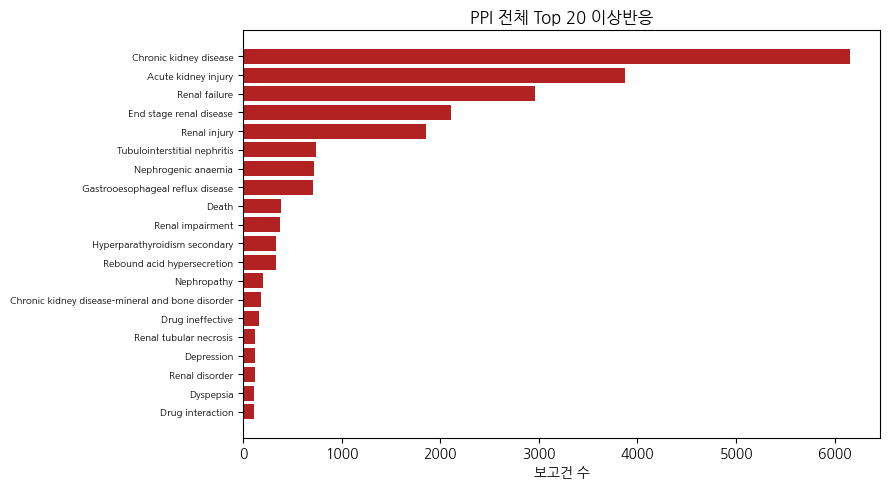

In [5]:
# reactions 분리 후 Top 20 부작용 분석
def split_reactions(x):
    if pd.isna(x): return []
    return [r.strip() for r in str(x).split(";") if r.strip() and r.strip().lower() != "nan"]

df_ppi["reaction_list"] = df_ppi["reactions"].apply(split_reactions)

reaction_records = []
for _, row in df_ppi[["row_id", "reaction_list", "serious", "age_group"]].iterrows():
    for reaction in sorted(set(row["reaction_list"])):
        reaction_records.append({"row_id": row["row_id"], "reaction": reaction, "serious": row["serious"], "age_group": row["age_group"]})
rx = pd.DataFrame(reaction_records)

top20 = rx["reaction"].value_counts().head(20).reset_index()
top20.columns = ["이상반응", "보고건 수"]
top20["PPI 보고건 대비 비율(%)"] = (top20["보고건 수"] / len(df_ppi) * 100).round(1)
top20["전체 reaction mention 대비 비율(%)"] = (top20["보고건 수"] / len(rx) * 100).round(1)
display(top20)

print("전체 reaction mention 수:", len(rx))
print("Top 5 reaction mention 비중:", round(top20.head(5)["보고건 수"].sum() / len(rx) * 100, 1), "%")
print("Top 20 reaction mention 비중:", round(top20["보고건 수"].sum() / len(rx) * 100, 1), "%")

top20_plot = top20.sort_values("보고건 수", ascending=True)
plt.figure(figsize=(9, 5))
plt.barh(top20_plot["이상반응"], top20_plot["보고건 수"], color=RED_MAIN)
plt.title("PPI 전체 Top 20 이상반응", fontsize=12, fontweight="bold")
plt.xlabel("보고건 수")
plt.yticks(fontsize=7)
plt.tight_layout()
plt.show()

In [6]:
# 연령대 매핑 및 분포
age_order = ["Infant(0-2)","Child(3-12)","Teen(13-18)","Adult(19-40)","Middle-Aged(41-65)","Senior(66-80)","Elderly(81+)","Unknown"]
age_map = {
    "Infant(0-2)":"유아(0-2)", "Child(3-12)":"아동(3-12)", "Teen(13-18)":"청소년(13-18)",
    "Adult(19-40)":"청년층(19-40)", "Middle-Aged(41-65)":"중장년층(41-65)",
    "Senior(66-80)":"고령층(66-80)", "Elderly(81+)":"초고령층(81+)", "Unknown":"연령 Unknown"
}
df_ppi["age_group_kr"] = df_ppi["age_group"].map(age_map).fillna(df_ppi["age_group"])
rx["age_group_kr"] = rx["age_group"].map(age_map).fillna(rx["age_group"])

age_dist = df_ppi["age_group"].value_counts().reindex(age_order).reset_index()
age_dist.columns = ["age_group", "보고건 수"]
age_dist["연령대"] = age_dist["age_group"].map(age_map)
age_dist["비율(%)"] = (age_dist["보고건 수"] / len(df_ppi) * 100).round(1)
display(age_dist[["연령대", "보고건 수", "비율(%)"]])

,연령대,보고건 수,비율(%)
0,유아(0-2),18,0.2
1,아동(3-12),30,0.3
2,청소년(13-18),13,0.1
3,청년층(19-40),513,5.8
4,중장년층(41-65),3574,40.3
5,고령층(66-80),1581,17.8
6,초고령층(81+),299,3.4
7,연령 Unknown,2851,32.1


,연령대,연령대 보고건 수,이상반응,이상반응 보고건 수,연령대 내 비율(%)
0,유아(0-2),18,Foetal exposure during pregnancy,8,44.4
1,유아(0-2),18,Premature baby,6,33.3
2,유아(0-2),18,Oesophageal atresia,3,16.7
3,유아(0-2),18,Teratogenicity,3,16.7
4,유아(0-2),18,Maternal exposure during pregnancy,2,11.1
5,아동(3-12),30,Drug interaction,4,13.3
6,아동(3-12),30,Rash papular,4,13.3
7,아동(3-12),30,Dermatitis acneiform,4,13.3
8,아동(3-12),30,Rash macular,3,10.0
9,아동(3-12),30,Erythema,3,10.0


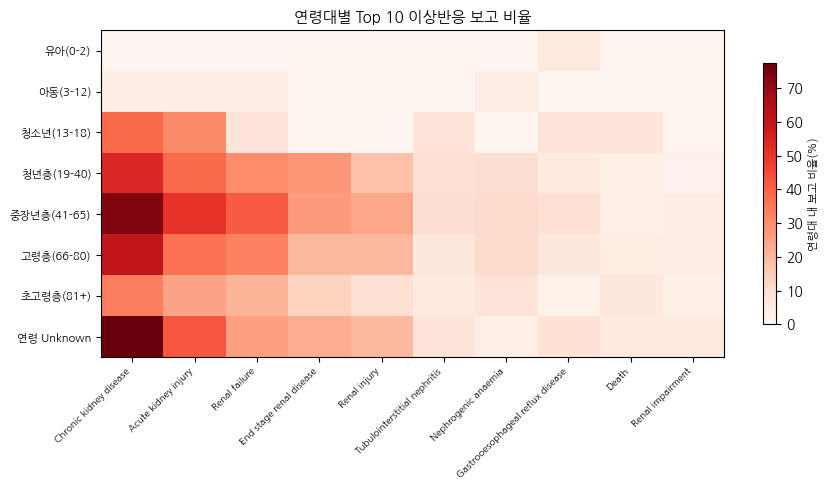

In [7]:
# 연령대별 Top 5 부작용 + Top 10 이상반응 보고 비율 히트맵
age_totals = df_ppi.groupby("age_group").size().to_dict()

age_top_rows = []
for age in age_order:
    sub = rx[rx["age_group"] == age]
    top5 = sub["reaction"].value_counts().head(5)
    total = age_totals.get(age, 0)
    for reaction, count in top5.items():
        age_top_rows.append({
            "연령대": age_map.get(age, age), "연령대 보고건 수": total, "이상반응": reaction,
            "이상반응 보고건 수": count, "연령대 내 비율(%)": round(count/total*100, 1) if total > 0 else np.nan
        })
age_top5 = pd.DataFrame(age_top_rows)
display(age_top5)

top10_reactions = top20["이상반응"].head(10).tolist()
heatmap_rows = []
for age in age_order:
    total = age_totals.get(age, 0)
    row = {"연령대": age_map.get(age, age)}
    for reaction in top10_reactions:
        count = len(rx[(rx["age_group"] == age) & (rx["reaction"] == reaction)])
        row[reaction] = count / total * 100 if total > 0 else 0
    heatmap_rows.append(row)
heatmap_df = pd.DataFrame(heatmap_rows).set_index("연령대")

plt.figure(figsize=(9, 5))
plt.imshow(heatmap_df.values, cmap="Reds", aspect="auto")
plt.title("연령대별 Top 10 이상반응 보고 비율", fontsize=11, fontweight="bold")
plt.xticks(ticks=np.arange(len(heatmap_df.columns)), labels=heatmap_df.columns, rotation=45, ha="right", fontsize=7)
plt.yticks(ticks=np.arange(len(heatmap_df.index)), labels=heatmap_df.index, fontsize=8)
cbar = plt.colorbar(shrink=0.8)
cbar.set_label("연령대 내 보고 비율(%)", fontsize=8)
plt.tight_layout()
plt.show()

,연령대,전체_보고건수,serious_보고건수,serious 비율(%)
3,유아(0-2),18,17,94.4
1,아동(3-12),30,25,83.3
6,청소년(13-18),13,13,100.0
0,청년층(19-40),513,504,98.2
4,중장년층(41-65),3574,3492,97.7
5,고령층(66-80),1581,1501,94.9
2,초고령층(81+),299,279,93.3
7,연령 Unknown,2851,2762,96.9


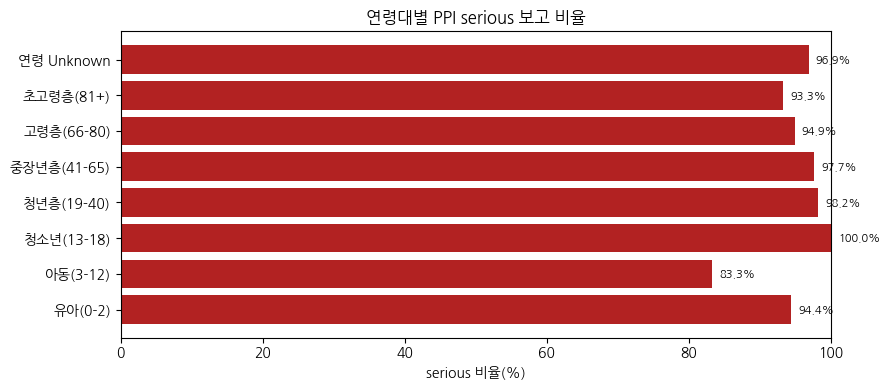

In [8]:
# 연령대별 serious 비율
age_serious = (
    df_ppi.groupby("age_group")
    .agg(전체_보고건수=("row_id","count"), serious_보고건수=("serious_bool","sum"))
    .reset_index()
)
age_serious["serious 비율(%)"] = (age_serious["serious_보고건수"] / age_serious["전체_보고건수"] * 100).round(1)
age_serious["연령대"] = age_serious["age_group"].map(age_map)
age_serious["age_group"] = pd.Categorical(age_serious["age_group"], categories=age_order, ordered=True)
age_serious = age_serious.sort_values("age_group")
display(age_serious[["연령대", "전체_보고건수", "serious_보고건수", "serious 비율(%)"]])

plt.figure(figsize=(9, 4))
plt.barh(age_serious["연령대"], age_serious["serious 비율(%)"], color=RED_MAIN)
plt.title("연령대별 PPI serious 보고 비율", fontsize=12, fontweight="bold")
plt.xlabel("serious 비율(%)")
plt.xlim(0, 100)
for i, value in enumerate(age_serious["serious 비율(%)"]):
    plt.text(value + 1, i, f"{value}%", va="center", fontsize=8)
plt.tight_layout()
plt.show()

In [9]:
# 통계분석 공통함수 (Cramer's V, Benjamini-Hochberg FDR 보정)
def cramers_v_from_table(table):
    chi2, p, dof, expected = chi2_contingency(table)
    n = table.to_numpy().sum()
    r, c = table.shape
    v = np.sqrt(chi2 / (n * (min(r-1, c-1))))
    return chi2, p, dof, v, expected.min()

def benjamini_hochberg(pvalues):
    pvalues = np.array(pvalues)
    n = len(pvalues)
    order = np.argsort(pvalues)
    ranked_p = pvalues[order]
    adjusted = ranked_p * n / (np.arange(1, n+1))
    adjusted = np.minimum.accumulate(adjusted[::-1])[::-1]
    adjusted = np.minimum(adjusted, 1)
    result = np.empty(n)
    result[order] = adjusted
    return result

In [10]:
# 통계분석 1: PPI 성분과 serious 여부
ingredient_serious_table = pd.crosstab(df_ppi["ppi_ingredient"], df_ppi["serious_bool"])
chi2, p, dof, v, expected_min = cramers_v_from_table(ingredient_serious_table)
print("[PPI 성분 x serious 여부 카이제곱 검정]")
print("Chi-square:", round(chi2, 3)); print("p-value:", f"{p:.3e}")
print("dof:", dof); print("Cramer's V:", round(v, 3)); print("Expected min:", round(expected_min, 3))

ingredient_serious = (
    df_ppi.groupby("ppi_ingredient")
    .agg(전체_보고건수=("row_id","count"), serious_보고건수=("serious_bool","sum"))
    .reset_index()
)
ingredient_serious["serious 비율(%)"] = (ingredient_serious["serious_보고건수"] / ingredient_serious["전체_보고건수"] * 100).round(1)
display(ingredient_serious)

[PPI 성분 x serious 여부 카이제곱 검정]
Chi-square: 47.059
p-value: 3.377e-10
dof: 3
Cramer's V: 0.073
Expected min: 54.63


,ppi_ingredient,전체_보고건수,serious_보고건수,serious 비율(%)
0,Esomeprazole,3238,3121,96.4
1,Lansoprazole,1975,1958,99.1
2,Omeprazole,1970,1890,95.9
3,Pantoprazole,1696,1624,95.8


In [11]:
# 통계분석 2: 연령대와 serious 여부 (표본 작은 소아/청소년, Unknown 제외)
stable_ages = ["Adult(19-40)", "Middle-Aged(41-65)", "Senior(66-80)", "Elderly(81+)"]
df_age_stable = df_ppi[df_ppi["age_group"].isin(stable_ages)].copy()

age_serious_table = pd.crosstab(df_age_stable["age_group"], df_age_stable["serious_bool"])
chi2, p, dof, v, expected_min = cramers_v_from_table(age_serious_table)
print("[연령대 x serious 여부 카이제곱 검정]")
print("분석 연령대:", stable_ages)
print("Chi-square:", round(chi2, 3)); print("p-value:", f"{p:.3e}")
print("dof:", dof); print("Cramer's V:", round(v, 3)); print("Expected min:", round(expected_min, 3))

[연령대 x serious 여부 카이제곱 검정]
분석 연령대: ['Adult(19-40)', 'Middle-Aged(41-65)', 'Senior(66-80)', 'Elderly(81+)']
Chi-square: 42.322
p-value: 3.428e-09
dof: 3
Cramer's V: 0.084
Expected min: 9.571


In [12]:
# 통계분석 3: Top 20 이상반응과 연령대 관련성 (FDR 보정)
df_reports = df_ppi[df_ppi["age_group"].isin(stable_ages)][["row_id", "age_group"]].copy()
rx_stable = rx[rx["age_group"].isin(stable_ages)].copy()

assoc_results = []
for reaction in top20["이상반응"].tolist():
    temp = df_reports.copy()
    present_ids = set(rx_stable.loc[rx_stable["reaction"] == reaction, "row_id"])
    temp["present"] = temp["row_id"].isin(present_ids)
    table = pd.crosstab(temp["age_group"], temp["present"])
    if table.shape[0] > 1 and table.shape[1] == 2:
        chi2, p, dof, expected = chi2_contingency(table)
        n = table.to_numpy().sum()
        v = np.sqrt(chi2 / (n * (min(table.shape[0]-1, table.shape[1]-1))))
        rates = temp.groupby("age_group")["present"].mean() * 100
        max_age, min_age = rates.idxmax(), rates.idxmin()
        assoc_results.append({
            "이상반응": reaction, "p-value": p, "Cramer's V": v,
            "가장 높은 연령대": age_map[max_age], "가장 높은 비율(%)": rates[max_age],
            "가장 낮은 연령대": age_map[min_age], "가장 낮은 비율(%)": rates[min_age],
            "Expected min": expected.min()
        })

assoc_df = pd.DataFrame(assoc_results)
assoc_df["FDR 보정 p-value"] = benjamini_hochberg(assoc_df["p-value"].values)
assoc_df = assoc_df.sort_values("FDR 보정 p-value")
assoc_df["Cramer's V"] = assoc_df["Cramer's V"].round(3)
assoc_df["가장 높은 비율(%)"] = assoc_df["가장 높은 비율(%)"].round(1)
assoc_df["가장 낮은 비율(%)"] = assoc_df["가장 낮은 비율(%)"].round(1)
assoc_df["FDR 보정 p-value"] = assoc_df["FDR 보정 p-value"].apply(lambda x: f"{x:.3e}")

display(assoc_df[["이상반응","FDR 보정 p-value","Cramer's V","가장 높은 연령대","가장 높은 비율(%)","가장 낮은 연령대","가장 낮은 비율(%)"]])

,이상반응,FDR 보정 p-value,Cramer's V,가장 높은 연령대,가장 높은 비율(%),가장 낮은 연령대,가장 낮은 비율(%)
0,Chronic kidney disease,9.204e-58,0.214,중장년층(41-65),72.9,초고령층(81+),33.4
1,Acute kidney injury,4.250e-31,0.158,중장년층(41-65),50.8,초고령층(81+),25.1
2,Renal failure,1.526e-17,0.120,중장년층(41-65),41.6,초고령층(81+),21.1
3,End stage renal disease,1.426e-11,0.098,청년층(19-40),28.1,초고령층(81+),13.0
4,Renal injury,2.375e-09,0.088,중장년층(41-65),24.0,초고령층(81+),9.4
7,Gastrooesophageal reflux disease,7.577e-07,0.075,중장년층(41-65),9.2,초고령층(81+),2.0
19,Drug interaction,3.288e-05,0.066,초고령층(81+),4.7,중장년층(41-65),1.1
5,Tubulointerstitial nephritis,4.421e-05,0.064,중장년층(41-65),10.0,초고령층(81+),5.4
15,Renal tubular necrosis,1.324e-03,0.054,중장년층(41-65),2.5,초고령층(81+),0.0
10,Hyperparathyroidism secondary,3.300e-03,0.050,중장년층(41-65),5.6,초고령층(81+),2.0


In [13]:
# Drug interaction / Death 여부 파생 및 연령대별 비율
df_ppi["has_drug_interaction"] = df_ppi["reaction_list"].apply(lambda x: "Drug interaction" in set(x))
df_ppi["has_death"] = df_ppi["reaction_list"].apply(lambda x: "Death" in set(x))
print("Drug interaction 보고건 수:", df_ppi["has_drug_interaction"].sum())
print("Death 보고건 수:", df_ppi["has_death"].sum())

age_summary = (
    df_ppi.groupby("age_group")
    .agg(PPI_보고건수=("row_id","count"), Drug_interaction_건수=("has_drug_interaction","sum"), Death_건수=("has_death","sum"))
    .reindex(age_order).reset_index()
)
age_summary["연령대"] = age_summary["age_group"].map(age_map)
age_summary["Drug interaction 비율(%)"] = (age_summary["Drug_interaction_건수"] / age_summary["PPI_보고건수"] * 100).round(1)
age_summary["Death 비율(%)"] = (age_summary["Death_건수"] / age_summary["PPI_보고건수"] * 100).round(1)
display(age_summary[["연령대","PPI_보고건수","Drug_interaction_건수","Drug interaction 비율(%)","Death_건수","Death 비율(%)"]])

Drug interaction 보고건 수: 113
Death 보고건 수: 383


,연령대,PPI_보고건수,Drug_interaction_건수,Drug interaction 비율(%),Death_건수,Death 비율(%)
0,유아(0-2),18,1,5.6,0,0.0
1,아동(3-12),30,4,13.3,0,0.0
2,청소년(13-18),13,3,23.1,1,7.7
3,청년층(19-40),513,9,1.8,14,2.7
4,중장년층(41-65),3574,40,1.1,115,3.2
5,고령층(66-80),1581,33,2.1,73,4.6
6,초고령층(81+),299,14,4.7,19,6.4
7,연령 Unknown,2851,9,0.3,161,5.6


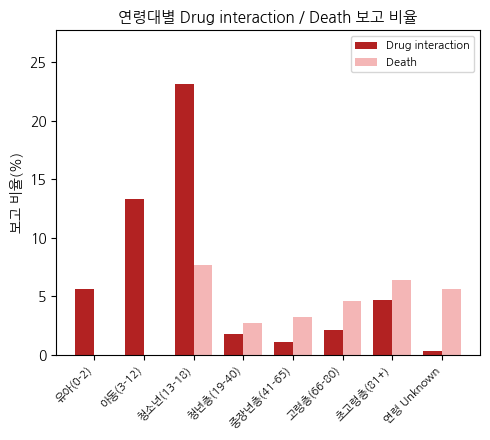

In [14]:
# 시각화: 전체 연령대별 Drug interaction / Death 비율
plot_df = age_summary.copy()
x = np.arange(len(plot_df)); width = 0.38
plt.figure(figsize=(5, 4.5))
plt.bar(x - width/2, plot_df["Drug interaction 비율(%)"], width, label="Drug interaction", color=RED_MAIN)
plt.bar(x + width/2, plot_df["Death 비율(%)"], width, label="Death", color=RED_LIGHT)
plt.title("연령대별 Drug interaction / Death 보고 비율", fontsize=11, fontweight="bold")
plt.ylabel("보고 비율(%)")
plt.xticks(x, plot_df["연령대"], rotation=45, ha="right", fontsize=8)
plt.legend(fontsize=8)
plt.ylim(0, max(plot_df["Drug interaction 비율(%)"].max(), plot_df["Death 비율(%)"].max()) * 1.2)
plt.tight_layout()
plt.show()

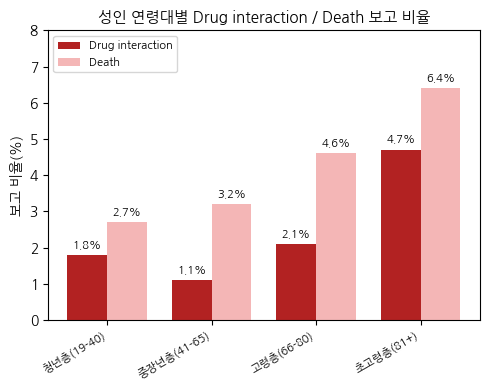

In [15]:
# 시각화: 성인 이상 안정 표본군(청년~초고령) 비교
stable_df = age_summary[age_summary["age_group"].isin(stable_ages)].copy()
x = np.arange(len(stable_df)); width = 0.38
plt.figure(figsize=(5, 4))
plt.bar(x - width/2, stable_df["Drug interaction 비율(%)"], width, label="Drug interaction", color=RED_MAIN)
plt.bar(x + width/2, stable_df["Death 비율(%)"], width, label="Death", color=RED_LIGHT)
plt.title("성인 연령대별 Drug interaction / Death 보고 비율", fontsize=11, fontweight="bold")
plt.ylabel("보고 비율(%)")
plt.xticks(x, stable_df["연령대"], rotation=30, ha="right", fontsize=8)
plt.legend(fontsize=8)
plt.ylim(0, max(stable_df["Drug interaction 비율(%)"].max(), stable_df["Death 비율(%)"].max()) * 1.25)
for i, value in enumerate(stable_df["Drug interaction 비율(%)"]):
    plt.text(i - width/2, value + 0.2, f"{value}%", ha="center", fontsize=8)
for i, value in enumerate(stable_df["Death 비율(%)"]):
    plt.text(i + width/2, value + 0.2, f"{value}%", ha="center", fontsize=8)
plt.tight_layout()
plt.show()

In [16]:
# 통계분석: 성인 연령대 x Drug interaction 여부
df_stable = df_ppi[df_ppi["age_group"].isin(stable_ages)].copy()
drug_interaction_table = pd.crosstab(df_stable["age_group"], df_stable["has_drug_interaction"]).reindex(stable_ages)
display(drug_interaction_table)

chi2, p, dof, expected = chi2_contingency(drug_interaction_table)
n = drug_interaction_table.to_numpy().sum()
r, c = drug_interaction_table.shape
cramers_v = np.sqrt(chi2 / (n * min(r-1, c-1)))

print("[성인 연령대 x Drug interaction 여부 카이제곱 검정]")
print("Chi-square:", round(chi2, 3)); print("p-value:", f"{p:.3e}")
print("dof:", dof); print("Cramer's V:", round(cramers_v, 3)); print("Expected min:", round(expected.min(), 3))

has_drug_interaction,False,True
age_group,,
Adult(19-40),504,9
Middle-Aged(41-65),3534,40
Senior(66-80),1548,33
Elderly(81+),285,14


[성인 연령대 x Drug interaction 여부 카이제곱 검정]
Chi-square: 25.61
p-value: 1.151e-05
dof: 3
Cramer's V: 0.066
Expected min: 4.81


,patient_sex,보고건수,serious_건수,serious 비율(%)
0,Female,4256,4061,95.4
1,Male,3119,3044,97.6
2,Unknown,1504,1488,98.9


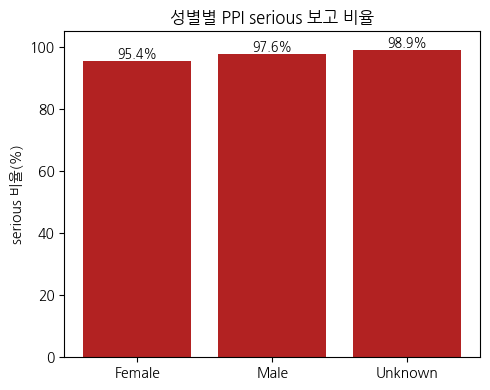

,성별,이상반응,보고건 수,성별 내 비율(%)
0,Female,Chronic kidney disease,2825,66.4
1,Female,Acute kidney injury,1793,42.1
2,Female,Renal failure,1461,34.3
3,Female,Renal injury,946,22.2
4,Female,End stage renal disease,883,20.7
5,Male,Chronic kidney disease,2092,67.1
6,Male,Acute kidney injury,1368,43.9
7,Male,Renal failure,1173,37.6
8,Male,End stage renal disease,847,27.2
9,Male,Renal injury,739,23.7


[성별 x serious 여부]
p-value: 1.539e-12
Cramer's V: 0.078


In [17]:
# 성별별 serious 비율 + Top 5 부작용
sex_summary = (
    df_ppi.groupby("patient_sex")
    .agg(보고건수=("row_id","count"), serious_건수=("serious_bool","sum"))
    .reset_index()
)
sex_summary["serious 비율(%)"] = (sex_summary["serious_건수"] / sex_summary["보고건수"] * 100).round(1)
display(sex_summary)

plt.figure(figsize=(5, 4))
plt.bar(sex_summary["patient_sex"], sex_summary["serious 비율(%)"], color=RED_MAIN)
plt.title("성별별 PPI serious 보고 비율", fontsize=12, fontweight="bold")
plt.ylabel("serious 비율(%)")
plt.ylim(0, 105)
for i, v in enumerate(sex_summary["serious 비율(%)"]):
    plt.text(i, v + 1, f"{v}%", ha="center", fontsize=9)
plt.tight_layout()
plt.show()

sex_top_rows = []
for sex in sex_summary["patient_sex"]:
    total = len(df_ppi[df_ppi["patient_sex"] == sex])
    top5 = rx.merge(df_ppi[["row_id","patient_sex"]], on="row_id")
    top5 = top5[top5["patient_sex"] == sex]["reaction"].value_counts().head(5)
    for reaction, count in top5.items():
        sex_top_rows.append({"성별": sex, "이상반응": reaction, "보고건 수": count, "성별 내 비율(%)": round(count/total*100, 1)})
sex_top5 = pd.DataFrame(sex_top_rows)
display(sex_top5)

sex_table = pd.crosstab(df_ppi["patient_sex"], df_ppi["serious_bool"])
chi2, p, dof, expected = chi2_contingency(sex_table)
n = sex_table.to_numpy().sum()
v = np.sqrt(chi2 / (n * min(sex_table.shape[0]-1, sex_table.shape[1]-1)))
print("[성별 x serious 여부]")
print("p-value:", f"{p:.3e}")
print("Cramer's V:", round(v, 3))

,weight_group,보고건수,serious_건수,serious 비율(%)
0,<50kg,123,116,94.3
1,50-59kg,265,240,90.6
2,60-69kg,475,443,93.3
3,70-79kg,595,572,96.1
4,80kg+,2062,2016,97.8
5,Unknown,5359,5206,97.1


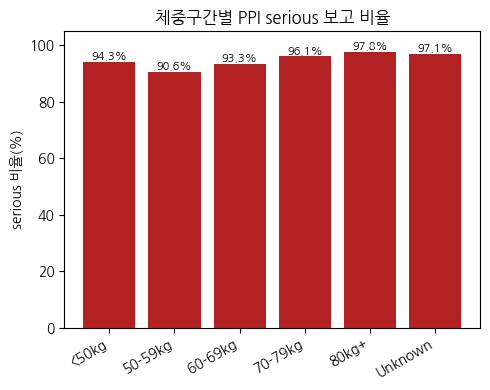

[체중구간 x serious 여부]
p-value: 2.148e-12
Cramer's V: 0.085


In [18]:
# 체중구간별 serious 비율 + Top 5 부작용
df_ppi["weight_num"] = pd.to_numeric(df_ppi["patient_weight_kg"].replace("Unknown", np.nan), errors="coerce")
df_ppi["weight_group"] = pd.cut(df_ppi["weight_num"], bins=[0,50,60,70,80,999],
                                 labels=["<50kg","50-59kg","60-69kg","70-79kg","80kg+"], right=False)
df_ppi["weight_group"] = df_ppi["weight_group"].cat.add_categories(["Unknown"]).fillna("Unknown")
weight_order = ["<50kg","50-59kg","60-69kg","70-79kg","80kg+","Unknown"]

weight_summary = (
    df_ppi.groupby("weight_group", observed=False)
    .agg(보고건수=("row_id","count"), serious_건수=("serious_bool","sum"))
    .reindex(weight_order).reset_index()
)
weight_summary["serious 비율(%)"] = (weight_summary["serious_건수"] / weight_summary["보고건수"] * 100).round(1)
display(weight_summary)

plt.figure(figsize=(5, 4))
plt.bar(weight_summary["weight_group"], weight_summary["serious 비율(%)"], color=RED_MAIN)
plt.title("체중구간별 PPI serious 보고 비율", fontsize=12, fontweight="bold")
plt.ylabel("serious 비율(%)")
plt.xticks(rotation=30, ha="right")
plt.ylim(0, 105)
for i, v in enumerate(weight_summary["serious 비율(%)"]):
    plt.text(i, v + 1, f"{v}%", ha="center", fontsize=8)
plt.tight_layout()
plt.show()

weight_table = pd.crosstab(df_ppi["weight_group"], df_ppi["serious_bool"])
chi2, p, dof, expected = chi2_contingency(weight_table)
n = weight_table.to_numpy().sum()
v = np.sqrt(chi2 / (n * min(weight_table.shape[0]-1, weight_table.shape[1]-1)))
print("[체중구간 x serious 여부]")
print("p-value:", f"{p:.3e}")
print("Cramer's V:", round(v, 3))

,ppi_ingredient,보고건수,serious_건수,serious 비율(%)
0,Esomeprazole,3238,3121,96.4
1,Lansoprazole,1975,1958,99.1
2,Omeprazole,1970,1890,95.9
3,Pantoprazole,1696,1624,95.8


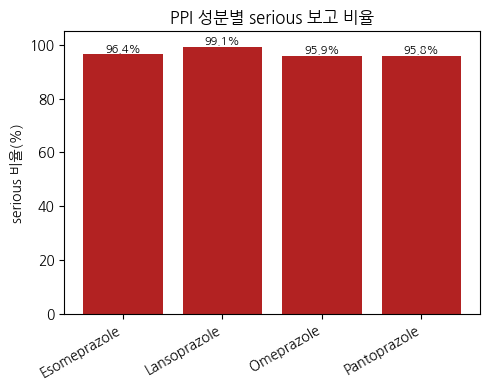

,PPI 성분,이상반응,보고건 수,성분 내 비율(%)
0,Esomeprazole,Chronic kidney disease,2512,77.6
1,Esomeprazole,Acute kidney injury,1641,50.7
2,Esomeprazole,Renal failure,1497,46.2
3,Esomeprazole,End stage renal disease,924,28.5
4,Esomeprazole,Renal injury,887,27.4
5,Lansoprazole,Chronic kidney disease,1512,76.6
6,Lansoprazole,Acute kidney injury,861,43.6
7,Lansoprazole,Renal failure,510,25.8
8,Lansoprazole,End stage renal disease,471,23.8
9,Lansoprazole,Renal injury,418,21.2


[PPI 성분 x serious 여부]
p-value: 3.377e-10
Cramer's V: 0.073


In [19]:
# PPI 성분별 Top 부작용 + serious 비율
ingredient_summary = (
    df_ppi.groupby("ppi_ingredient")
    .agg(보고건수=("row_id","count"), serious_건수=("serious_bool","sum"))
    .reset_index()
)
ingredient_summary["serious 비율(%)"] = (ingredient_summary["serious_건수"] / ingredient_summary["보고건수"] * 100).round(1)
display(ingredient_summary)

plt.figure(figsize=(5, 4))
plt.bar(ingredient_summary["ppi_ingredient"], ingredient_summary["serious 비율(%)"], color=RED_MAIN)
plt.title("PPI 성분별 serious 보고 비율", fontsize=12, fontweight="bold")
plt.ylabel("serious 비율(%)")
plt.xticks(rotation=30, ha="right")
plt.ylim(0, 105)
for i, v in enumerate(ingredient_summary["serious 비율(%)"]):
    plt.text(i, v + 1, f"{v}%", ha="center", fontsize=8)
plt.tight_layout()
plt.show()

ingredient_top_rows = []
for ing in ingredient_summary["ppi_ingredient"]:
    total = len(df_ppi[df_ppi["ppi_ingredient"] == ing])
    top5 = rx.merge(df_ppi[["row_id","ppi_ingredient"]], on="row_id")
    top5 = top5[top5["ppi_ingredient"] == ing]["reaction"].value_counts().head(5)
    for reaction, count in top5.items():
        ingredient_top_rows.append({"PPI 성분": ing, "이상반응": reaction, "보고건 수": count, "성분 내 비율(%)": round(count/total*100, 1)})
ingredient_top5 = pd.DataFrame(ingredient_top_rows)
display(ingredient_top5)

ingredient_table = pd.crosstab(df_ppi["ppi_ingredient"], df_ppi["serious_bool"])
chi2, p, dof, expected = chi2_contingency(ingredient_table)
n = ingredient_table.to_numpy().sum()
v = np.sqrt(chi2 / (n * min(ingredient_table.shape[0]-1, ingredient_table.shape[1]-1)))
print("[PPI 성분 x serious 여부]")
print("p-value:", f"{p:.3e}")
print("Cramer's V:", round(v, 3))

,num_drugs_group,보고건수,serious_건수,serious 비율(%)
0,1개,206,136,66.0
1,2-3개,500,443,88.6
2,4-5개,491,452,92.1
3,6-9개,1047,987,94.3
4,10개 이상,6635,6575,99.1


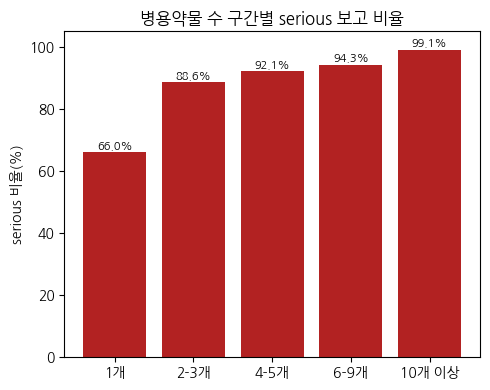

[병용약물 수 구간 x serious 여부]
p-value: 3.650e-194
Cramer's V: 0.319
[10개 이상 vs 10개 미만]
Odds Ratio: 12.272
95% CI: 9.192 ~ 16.385
Fisher p-value: 6.550e-84


In [20]:
# 병용약물 수와 serious 여부
df_ppi["num_drugs_group"] = pd.cut(df_ppi["num_drugs"], bins=[0,1,3,5,9,999999],
                                    labels=["1개","2-3개","4-5개","6-9개","10개 이상"], right=True)
num_summary = (
    df_ppi.groupby("num_drugs_group", observed=False)
    .agg(보고건수=("row_id","count"), serious_건수=("serious_bool","sum"))
    .reset_index()
)
num_summary["serious 비율(%)"] = (num_summary["serious_건수"] / num_summary["보고건수"] * 100).round(1)
display(num_summary)

plt.figure(figsize=(5, 4))
plt.bar(num_summary["num_drugs_group"], num_summary["serious 비율(%)"], color=RED_MAIN)
plt.title("병용약물 수 구간별 serious 보고 비율", fontsize=12, fontweight="bold")
plt.ylabel("serious 비율(%)")
plt.ylim(0, 105)
for i, v in enumerate(num_summary["serious 비율(%)"]):
    plt.text(i, v + 1, f"{v}%", ha="center", fontsize=8)
plt.tight_layout()
plt.show()

num_table = pd.crosstab(df_ppi["num_drugs_group"], df_ppi["serious_bool"])
chi2, p, dof, expected = chi2_contingency(num_table)
n = num_table.to_numpy().sum()
v = np.sqrt(chi2 / (n * min(num_table.shape[0]-1, num_table.shape[1]-1)))
print("[병용약물 수 구간 x serious 여부]")
print("p-value:", f"{p:.3e}")
print("Cramer's V:", round(v, 3))

high = df_ppi[df_ppi["num_drugs"] >= 10]
low = df_ppi[df_ppi["num_drugs"] < 10]
a = high["serious_bool"].sum(); b = len(high) - a
c = low["serious_bool"].sum(); d = len(low) - c
or_value = (a * d) / (b * c)
se = math.sqrt(1/a + 1/b + 1/c + 1/d)
ci_low = math.exp(math.log(or_value) - 1.96*se)
ci_high = math.exp(math.log(or_value) + 1.96*se)
_, fisher_p = fisher_exact([[a, b], [c, d]])

print("[10개 이상 vs 10개 미만]")
print("Odds Ratio:", round(or_value, 3))
print("95% CI:", round(ci_low, 3), "~", round(ci_high, 3))
print("Fisher p-value:", f"{fisher_p:.3e}")

In [21]:
# 로지스틱 회귀분석 (연령대·성별·체중대·성분·병용약물수 -> serious)
age_model_map = {
    "Infant(0-2)": "0-18", "Child(3-12)": "0-18", "Teen(13-18)": "0-18",
    "Adult(19-40)": "19-40", "Middle-Aged(41-65)": "41-65",
    "Senior(66-80)": "66-80", "Elderly(81+)": "81+", "Unknown": "Unknown"
}
df_ppi["age_model"] = df_ppi["age_group"].map(age_model_map).fillna("Unknown")
df_ppi["weight_model"] = df_ppi["weight_group"].astype(str)
df_ppi["log_num_drugs"] = np.log1p(df_ppi["num_drugs"])
df_ppi["serious_int"] = df_ppi["serious_bool"].astype(int)

df_model = df_ppi[
    (df_ppi["age_model"].isin(["19-40","41-65","66-80","81+"])) &
    (df_ppi["patient_sex"].isin(["Male","Female"])) &
    (df_ppi["weight_model"] != "Unknown")
].copy()

formula = '''
serious_int ~
C(age_model, Treatment(reference="19-40")) +
C(patient_sex, Treatment(reference="Male")) +
C(weight_model, Treatment(reference="60-69kg")) +
C(ppi_ingredient, Treatment(reference="Omeprazole")) +
log_num_drugs
'''

model = smf.logit(formula, data=df_model).fit(maxiter=200)
params, conf, pvals = model.params, model.conf_int(), model.pvalues

logit_result = pd.DataFrame({
    "변수": params.index, "OR": np.exp(params).round(3),
    "95% CI 하한": np.exp(conf[0]).round(3), "95% CI 상한": np.exp(conf[1]).round(3),
    "p-value": pvals
})
logit_result["p-value"] = logit_result["p-value"].apply(lambda x: f"{x:.3e}")
display(logit_result)

Optimization terminated successfully.
         Current function value: 0.100673
         Iterations 9


,변수,OR,95% CI 하한,95% CI 상한,p-value
Intercept,Intercept,0.727,0.227,2.326,5.915e-01
"C(age_model, Treatment(reference=""19-40""))[T.41-65]","C(age_model, Treatment(reference=""19-40""))[T.4...",0.648,0.252,1.666,3.683e-01
"C(age_model, Treatment(reference=""19-40""))[T.66-80]","C(age_model, Treatment(reference=""19-40""))[T.6...",0.302,0.117,0.777,1.298e-02
"C(age_model, Treatment(reference=""19-40""))[T.81+]","C(age_model, Treatment(reference=""19-40""))[T.81+]",0.468,0.149,1.464,1.919e-01
"C(patient_sex, Treatment(reference=""Male""))[T.Female]","C(patient_sex, Treatment(reference=""Male""))[T....",0.456,0.273,0.761,2.653e-03
"C(weight_model, Treatment(reference=""60-69kg""))[T.50-59kg]","C(weight_model, Treatment(reference=""60-69kg"")...",0.448,0.217,0.923,2.958e-02
"C(weight_model, Treatment(reference=""60-69kg""))[T.70-79kg]","C(weight_model, Treatment(reference=""60-69kg"")...",1.024,0.500,2.097,9.482e-01
"C(weight_model, Treatment(reference=""60-69kg""))[T.80kg+]","C(weight_model, Treatment(reference=""60-69kg"")...",0.970,0.515,1.828,9.251e-01
"C(weight_model, Treatment(reference=""60-69kg""))[T.<50kg]","C(weight_model, Treatment(reference=""60-69kg"")...",0.640,0.215,1.902,4.217e-01
"C(ppi_ingredient, Treatment(reference=""Omeprazole""))[T.Esomeprazole]","C(ppi_ingredient, Treatment(reference=""Omepraz...",0.578,0.338,0.988,4.511e-02


## 파트 2. PPI ROR 신호탐지 및 장기계통·중증도 심층 분석

(파트 1과 별도의 PPI 정의 방식을 사용합니다: 성분명 매칭 OR `pharm_class == 'Proton Pump Inhibitor [EPC]'`)

In [22]:
import seaborn as sns
from statsmodels.stats.multitest import multipletests
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', font=plt.rcParams["font.family"])
plt.rcParams['figure.dpi'] = 110
plt.rcParams['figure.figsize'] = (10, 6)

# 하이브리드 규칙: (약품명에 PPI 성분 포함) OR (약효분류가 PPI)
ppi_keywords = 'omeprazole|esomeprazole|pantoprazole|lansoprazole|rabeprazole|dexlansoprazole'
name_mask = df['suspect_drug'].str.contains(ppi_keywords, case=False, na=False)
class_mask = df['pharm_class'] == 'Proton Pump Inhibitor [EPC]'
df['is_ppi'] = name_mask | class_mask

ppi = df[df['is_ppi']].copy()          # 분석 대상(PPI)
background = df[~df['is_ppi']].copy()  # 배경군(비PPI) - ROR 계산용

print(f'PPI 분석대상 : {len(ppi):,}건 ({len(ppi)/len(df)*100:.1f}%)')
print(f'   배경군(비PPI): {len(background):,}건')
print(f'   PPI의 ATC군  : {ppi["WHO_ATC"].unique()}')

PPI 분석대상 : 8,853건 (48.4%)
   배경군(비PPI): 9,420건
   PPI의 ATC군  : ['A']


In [23]:
# 대표 성분 태깅 + 연령/성별/체중 파생 변수
def tag_ingredient(text):
    """suspect_drug 텍스트에서 대표 PPI 성분 하나를 추출.
       주의: 'esomeprazole'은 'omeprazole'을 포함하므로 반드시 먼저 검사!"""
    t = str(text).lower()
    if 'dexlansoprazole' in t: return '덱스란소프라졸'
    if 'esomeprazole'   in t: return '에스오메프라졸'
    if 'omeprazole'     in t: return '오메프라졸'
    if 'lansoprazole'   in t: return '란소프라졸'
    if 'pantoprazole'   in t: return '판토프라졸'
    if 'rabeprazole'    in t: return '라베프라졸'
    return '기타/미분류'

ppi['ingredient'] = ppi['suspect_drug'].apply(tag_ingredient)
print('=== 성분별 건수 ===')
print(ppi['ingredient'].value_counts())
print(f'미분류 잔여: {(ppi["ingredient"]=="기타/미분류").sum()}건 (0이면 정상)')

ppi['age_num'] = pd.to_numeric(ppi['patient_age_years'], errors='coerce')
ppi.loc[(ppi['age_num'] <= 0) | (ppi['age_num'] > 120), 'age_num'] = np.nan
ppi['sex'] = ppi['patient_sex'].where(ppi['patient_sex'].isin(['Male','Female']), 'Unknown')
ppi['weight_num'] = pd.to_numeric(ppi['patient_weight_kg'], errors='coerce')
ppi.loc[(ppi['weight_num'] < 5) | (ppi['weight_num'] > 300), 'weight_num'] = np.nan

def age_band(a):
    if pd.isna(a):  return 'Unknown'
    if a <= 18:     return '소아(0-18)'
    if a <= 40:     return '청년(19-40)'
    if a <= 65:     return '중년(41-65)'
    if a <= 80:     return '노년(66-80)'
    return '초고령(81+)'
ppi['age_band'] = ppi['age_num'].apply(age_band)

ppi['weight_band'] = pd.cut(ppi['weight_num'], bins=[0,50,70,90,300], labels=['<50kg','50-69kg','70-89kg','90kg+'])

=== 성분별 건수 ===
ingredient
에스오메프라졸    3230
란소프라졸      1972
오메프라졸      1958
판토프라졸      1693
Name: count, dtype: int64
미분류 잔여: 0건 (0이면 정상)


In [24]:
# 케이스x반응 롱포맷 + 장기계통 그룹화
ppi['reaction_list'] = ppi['reactions'].fillna('').str.split(';')
reac = ppi.explode('reaction_list').copy()
reac['reaction_list'] = reac['reaction_list'].str.strip()
reac = reac[reac['reaction_list'] != '']

def organ_system(pt):
    t = str(pt).lower()
    if any(k in t for k in ['renal','kidney','nephr','glomerul','dialysis','proteinuria',
                            'tubulointerstitial','creatinine','dysuria','haematuria',
                            'nocturia','urin','micturition']):            return '신장/비뇨'
    if any(k in t for k in ['hepat','liver','jaundice','bilirubin','cholestasis']): return '간/담도'
    if any(k in t for k in ['gastr','oesoph','esoph','dyspep','diarrho','nausea','vomit',
                            'abdominal','constipation','reflux','hyperchlorhydria','acid',
                            'stomach','intestin','colitis','bowel']):      return '소화기'
    if any(k in t for k in ['anaemia','anemia','thrombocyt','leukop','neutrop',
                            'pancytop','platelet']):                       return '혈액'
    if any(k in t for k in ['cardiac','arrhythm','myocard','tachycard','hypertens',
                            'palpitation','heart','coronary']):            return '심혈관'
    if any(k in t for k in ['depression','anxiety','insomnia','confusion','psychiat',
                            'mood','suicid','dizz','headache']):           return '정신/신경'
    if any(k in t for k in ['fracture','bone','osteoporos','parathyroid','magnes','calc',
                            'natraem','kalaem','kalemia','electrolyte','arthralgia',
                            'mineral']):                                   return '뼈/전해질'
    if any(k in t for k in ['rash','pruritus','urticaria','erythema','dermat','stevens',
                            'skin','hypersensitivity']):                   return '피부/과민'
    if any(k in t for k in ['pneumon','dyspnoea','respirat','cough','lung','asthma',
                            'pulmonary']):                                 return '호흡기'
    if any(k in t for k in ['death','fatal']):                            return '사망'
    if any(k in t for k in ['drug ineffective','off label','misuse','interaction','overdose',
                            'product use','incorrect','wrong','medication error','rebound',
                            'toxicity']):                                  return '약물사용/오류'
    return '기타(일반증상)'
reac['organ'] = reac['reaction_list'].apply(organ_system)

print(f'케이스 테이블(ppi): {ppi.shape[0]:,}행 x {ppi.shape[1]}열')
print(f'반응 테이블(reac) : {reac.shape[0]:,}행 (케이스x반응)')

케이스 테이블(ppi): 8,853행 x 36열
반응 테이블(reac) : 31,506행 (케이스x반응)


In [25]:
# 결측률 요약
def coverage(col, is_sex=False):
    valid = (ppi[col] != 'Unknown').sum() if is_sex else ppi[col].notna().sum()
    return valid, len(ppi)-valid, valid/len(ppi)*100

rows = []
for col, label, is_sex in [('age_num','연령',False), ('sex','성별',True), ('weight_num','체중',False)]:
    v, m, pct = coverage(col, is_sex)
    rows.append({'변수':label, '유효':v, '결측':m, '커버리지(%)':round(pct,1)})
miss_table = pd.DataFrame(rows)
print(f'=== 결측률 요약 (전체 N={len(ppi):,}) ===')
print(miss_table.to_string(index=False))

=== 결측률 요약 (전체 N=8,853) ===
변수   유효   결측  커버리지(%)
연령 6010 2843     67.9
성별 7351 1502     83.0
체중 3495 5358     39.5


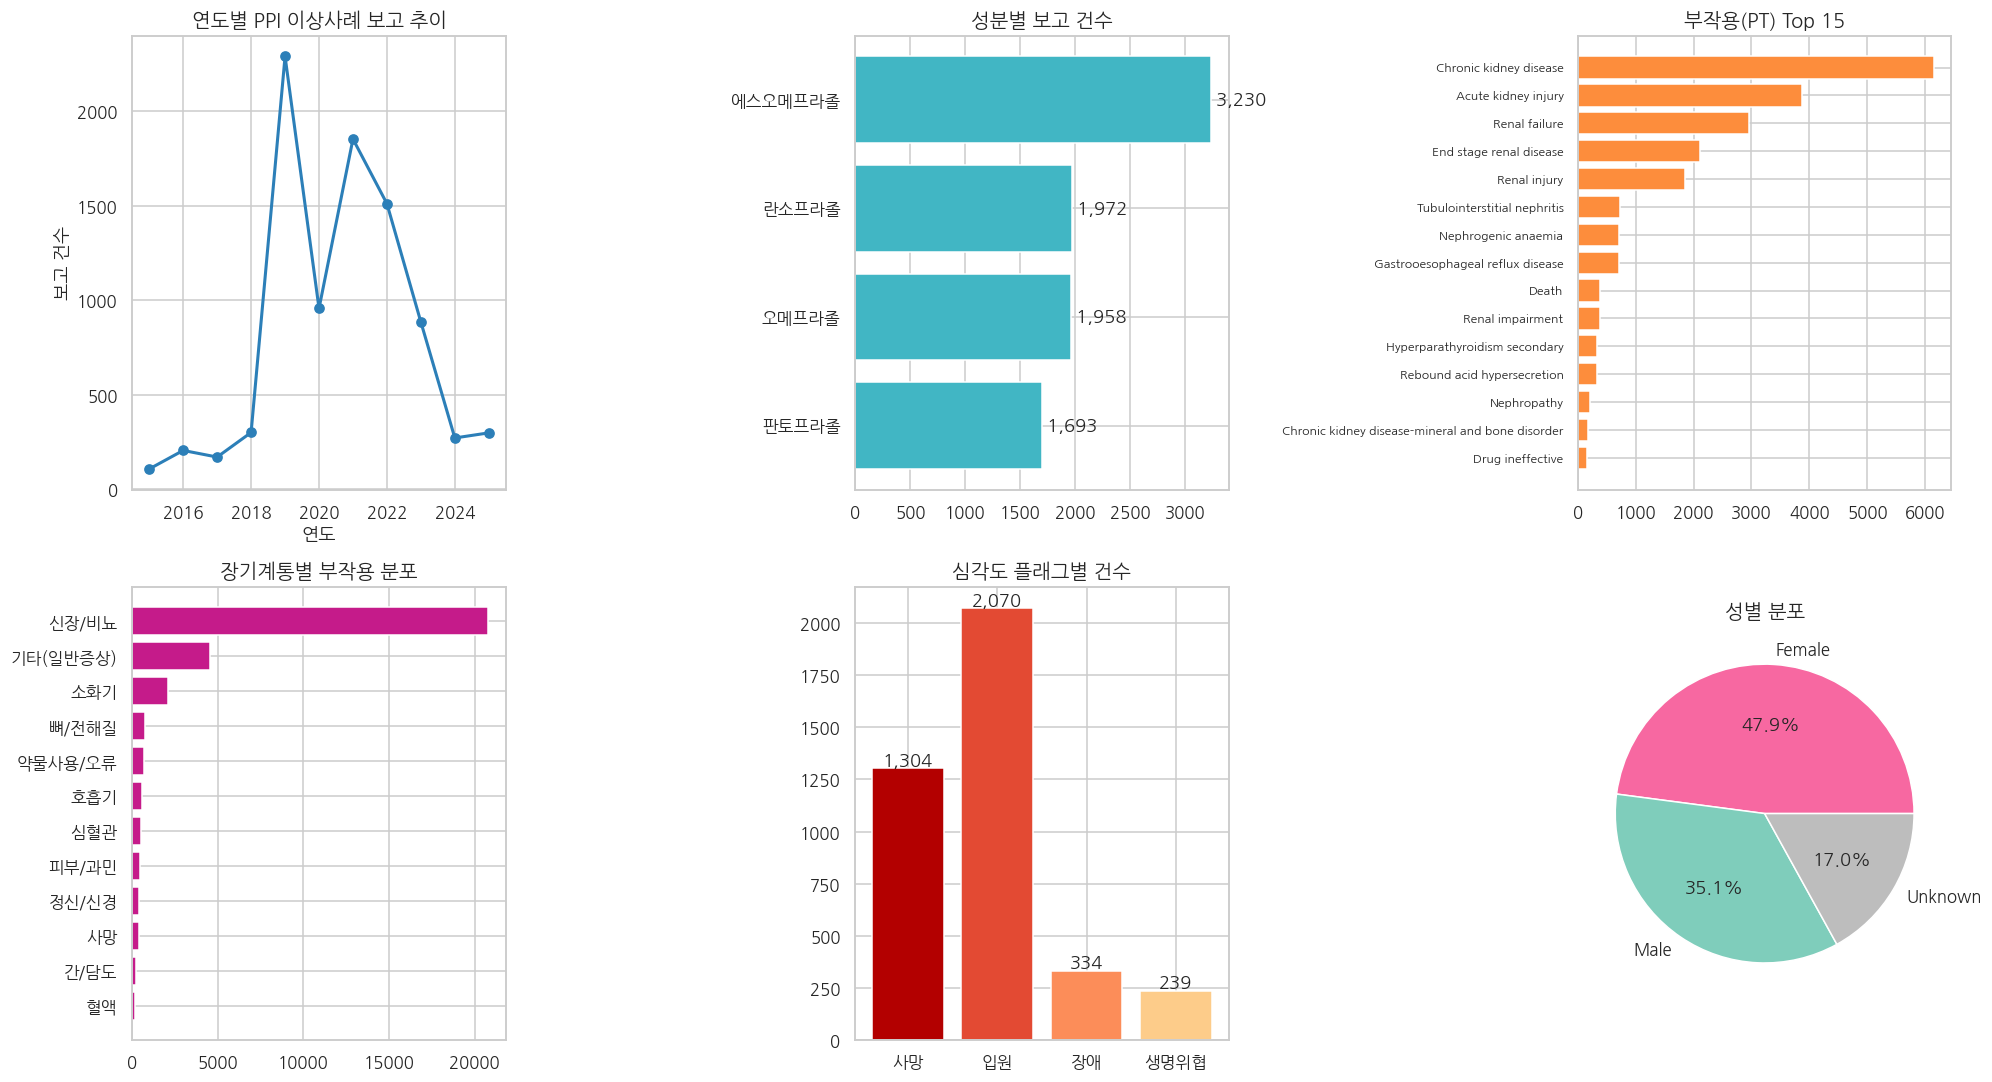

분석대상 PPI 케이스 : 8,853건
보고 기간           : 2015 ~ 2025
평균 부작용 수/건   : 5.2개
---------------------------------------------
【심각도】
  사망     : 1,304건 (14.7%)
  입원     : 2,070건 (23.4%)
---------------------------------------------
【장기계통 Top 3】
  신장/비뇨 : 20,787건 (66.0%)
  기타(일반증상) : 4,520건 (14.3%)
  소화기 : 2,082건 (6.6%)


In [26]:
# EDA 종합 (연도별 추이/성분별/부작용Top15/장기계통/심각도/성별)
ppi['year'] = pd.to_datetime(ppi['receive_date'], errors='coerce').dt.year

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

yr = ppi['year'].value_counts().sort_index()
axes[0,0].plot(yr.index, yr.values, marker='o', color='#2c7fb8', lw=2)
axes[0,0].set_title('연도별 PPI 이상사례 보고 추이', fontsize=13, fontweight='bold')
axes[0,0].set_xlabel('연도'); axes[0,0].set_ylabel('보고 건수')

ing = ppi['ingredient'].value_counts()
axes[0,1].barh(ing.index[::-1], ing.values[::-1], color='#41b6c4')
axes[0,1].set_title('성분별 보고 건수', fontsize=13, fontweight='bold')
for i, v in enumerate(ing.values[::-1]):
    axes[0,1].text(v, i, f' {v:,}', va='center')

top = reac['reaction_list'].value_counts().head(15)
axes[0,2].barh(top.index[::-1], top.values[::-1], color='#fd8d3c')
axes[0,2].set_title('부작용(PT) Top 15', fontsize=13, fontweight='bold')
axes[0,2].tick_params(axis='y', labelsize=8)

org = reac['organ'].value_counts()
axes[1,0].barh(org.index[::-1], org.values[::-1], color='#c51b8a')
axes[1,0].set_title('장기계통별 부작용 분포', fontsize=13, fontweight='bold')

sev = pd.Series({'사망':ppi['is_fatal'].sum(), '입원':ppi['is_hospitalized'].sum(),
                 '장애':ppi['is_disabling'].sum(), '생명위협':ppi['is_life_threat'].sum()})
axes[1,1].bar(sev.index, sev.values, color=['#b30000','#e34a33','#fc8d59','#fdcc8a'])
axes[1,1].set_title('심각도 플래그별 건수', fontsize=13, fontweight='bold')
for i, v in enumerate(sev.values):
    axes[1,1].text(i, v, f'{v:,}', ha='center', va='bottom')

sx = ppi['sex'].value_counts()
axes[1,2].pie(sx.values, labels=sx.index, autopct='%1.1f%%', colors=['#f768a1','#7fcdbb','#bdbdbd'])
axes[1,2].set_title('성별 분포', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

print('='*45)
print(f'분석대상 PPI 케이스 : {len(ppi):,}건')
print(f'보고 기간           : {ppi["year"].min():.0f} ~ {ppi["year"].max():.0f}')
print(f'평균 부작용 수/건   : {pd.to_numeric(ppi["num_reactions"],errors="coerce").mean():.1f}개')
print('-'*45)
print('【심각도】')
print(f'  사망     : {ppi["is_fatal"].sum():,}건 ({ppi["is_fatal"].mean()*100:.1f}%)')
print(f'  입원     : {ppi["is_hospitalized"].sum():,}건 ({ppi["is_hospitalized"].mean()*100:.1f}%)')
print('-'*45)
print('【장기계통 Top 3】')
for name, cnt in reac['organ'].value_counts().head(3).items():
    print(f'  {name} : {cnt:,}건 ({cnt/len(reac)*100:.1f}%)')
print('='*45)

In [27]:
reac = reac.reset_index(drop=True)   # explode 후 중복 인덱스 -> crosstab 오류 방지

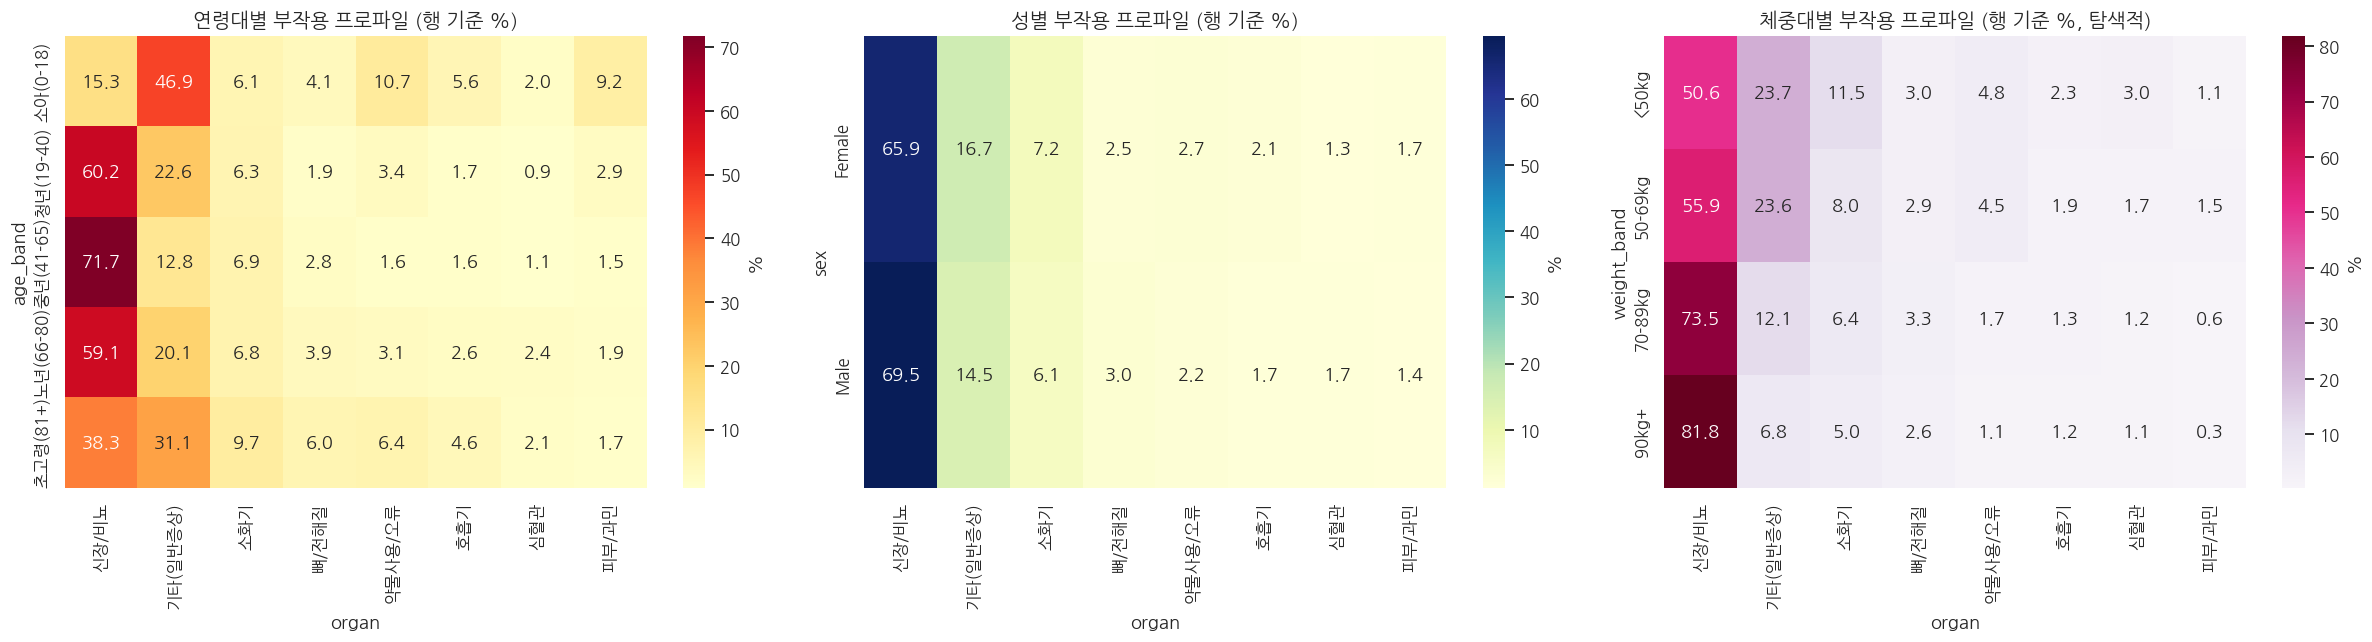

In [28]:
# 연령대/성별/체중대별 부작용 프로파일 히트맵 (장기계통 Top8 기준)
top_organ = reac['organ'].value_counts().head(8).index.tolist()

def row_pct(sub, idx_col, order=None):
    """행(연령대 등) 기준 % 교차표"""
    ct = pd.crosstab(sub[idx_col], sub['organ'])[top_organ]
    pct = ct.div(ct.sum(axis=1), axis=0) * 100
    if order:
        pct = pct.reindex([o for o in order if o in pct.index])
    return pct

fig, axes = plt.subplots(1, 3, figsize=(22, 6))
age_order = ['소아(0-18)','청년(19-40)','중년(41-65)','노년(66-80)','초고령(81+)']
wt_order  = ['<50kg','50-69kg','70-89kg','90kg+']

sns.heatmap(row_pct(reac[reac['age_band']!='Unknown'],'age_band',age_order),
            annot=True, fmt='.1f', cmap='YlOrRd', ax=axes[0], cbar_kws={'label':'%'})
axes[0].set_title('연령대별 부작용 프로파일 (행 기준 %)', fontsize=13, fontweight='bold')

sns.heatmap(row_pct(reac[reac['sex']!='Unknown'],'sex'),
            annot=True, fmt='.1f', cmap='YlGnBu', ax=axes[1], cbar_kws={'label':'%'})
axes[1].set_title('성별 부작용 프로파일 (행 기준 %)', fontsize=13, fontweight='bold')

sns.heatmap(row_pct(reac[reac['weight_band'].notna()],'weight_band',wt_order),
            annot=True, fmt='.1f', cmap='PuRd', ax=axes[2], cbar_kws={'label':'%'})
axes[2].set_title('체중대별 부작용 프로파일 (행 기준 %, 탐색적)', fontsize=13, fontweight='bold')

plt.tight_layout(); plt.show()

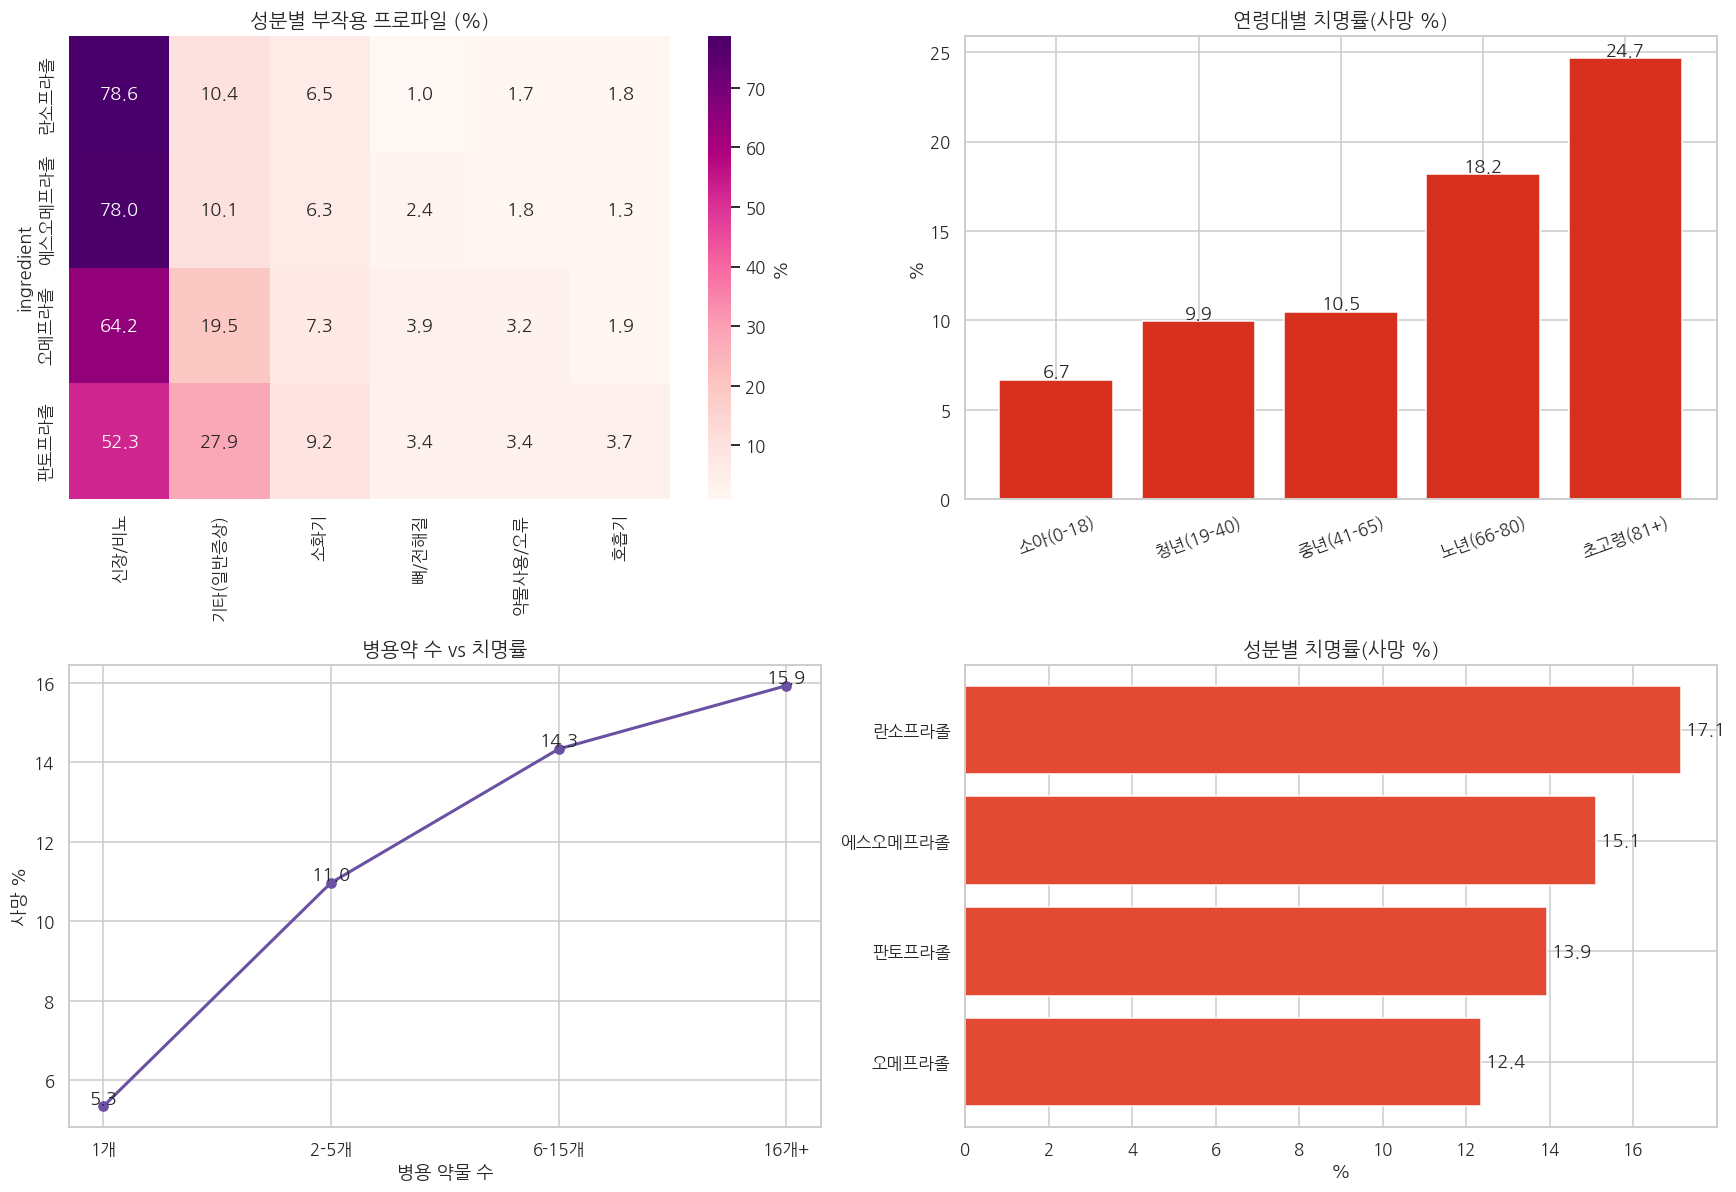

In [29]:
# 성분별 프로파일 / 연령대별 치명률 / 병용약수-치명률 / 성분별 치명률
fig, ax = plt.subplots(2, 2, figsize=(16, 11))

top6 = reac['organ'].value_counts().head(6).index.tolist()
ing_ct = pd.crosstab(reac['ingredient'], reac['organ'])[top6]
sns.heatmap(ing_ct.div(ing_ct.sum(axis=1),axis=0)*100, annot=True, fmt='.1f',
            cmap='RdPu', ax=ax[0,0], cbar_kws={'label':'%'})
ax[0,0].set_title('성분별 부작용 프로파일 (%)', fontsize=13, fontweight='bold'); ax[0,0].set_xlabel('')

fa = (ppi[ppi['age_band']!='Unknown'].groupby('age_band')['is_fatal'].mean()*100).reindex(age_order)
ax[0,1].bar(range(len(fa)), fa.values, color='#d7301f')
ax[0,1].set_xticks(range(len(fa))); ax[0,1].set_xticklabels(fa.index, rotation=20)
ax[0,1].set_title('연령대별 치명률(사망 %)', fontsize=13, fontweight='bold'); ax[0,1].set_ylabel('%')
for i,v in enumerate(fa.values): ax[0,1].text(i,v,f'{v:.1f}',ha='center',va='bottom')

ppi['ndrugs'] = pd.to_numeric(ppi['num_drugs'], errors='coerce')
ppi['dg'] = pd.cut(ppi['ndrugs'], [0,1,5,15,1000], labels=['1개','2-5개','6-15개','16개+'])
dd = ppi.groupby('dg')['is_fatal'].mean()*100
ax[1,0].plot(range(len(dd)), dd.values, marker='o', lw=2, color='#6a51a3')
ax[1,0].set_xticks(range(len(dd))); ax[1,0].set_xticklabels(dd.index)
ax[1,0].set_title('병용약 수 vs 치명률', fontsize=13, fontweight='bold')
ax[1,0].set_ylabel('사망 %'); ax[1,0].set_xlabel('병용 약물 수')
for i,v in enumerate(dd.values): ax[1,0].text(i,v,f'{v:.1f}',ha='center',va='bottom')

fi = (ppi.groupby('ingredient')['is_fatal'].mean()*100).sort_values()
ax[1,1].barh(fi.index, fi.values, color='#e34a33')
ax[1,1].set_title('성분별 치명률(사망 %)', fontsize=13, fontweight='bold'); ax[1,1].set_xlabel('%')
for i,v in enumerate(fi.values): ax[1,1].text(v,i,f' {v:.1f}',va='center')

plt.tight_layout(); plt.show()

In [30]:
# PPI vs 배경군(비PPI) ROR 신호탐지 준비
import matplotlib as mpl
mpl.rcParams['axes.formatter.use_mathtext'] = True

def explode_reactions(d):
    """어떤 데이터프레임이든 반응을 explode해서 반환"""
    d = d.copy()
    d['reaction_list'] = d['reactions'].fillna('').str.split(';')
    e = d.explode('reaction_list')
    e['reaction_list'] = e['reaction_list'].str.strip()
    return e[e['reaction_list'] != ''].reset_index(drop=True)

bg_reac = explode_reactions(background)

ppi_pt = reac.groupby('reaction_list')['report_id'].nunique()
bg_pt  = bg_reac.groupby('reaction_list')['report_id'].nunique()
N_ppi  = ppi['report_id'].nunique()
N_bg   = background['report_id'].nunique()

def compute_ror(a, N_exp, c, N_ref):
    """2x2 분할표에서 ROR·95%CI 계산 (Haldane-Anscombe 0.5 보정)"""
    b, d = N_exp - a, N_ref - c
    aa, bb, cc, dd = a+0.5, b+0.5, c+0.5, d+0.5
    ror = (aa*dd) / (bb*cc)
    se  = np.sqrt(1/aa + 1/bb + 1/cc + 1/dd)
    lo  = np.exp(np.log(ror) - 1.96*se)
    hi  = np.exp(np.log(ror) + 1.96*se)
    prr = (a/N_exp) / (c/N_ref) if c > 0 else np.nan
    return ror, lo, hi, prr

In [31]:
# PPI 부작용 Top 20 ROR 계산
rows = []
for pt in ppi_pt.sort_values(ascending=False).head(20).index:
    a, c = ppi_pt.get(pt, 0), bg_pt.get(pt, 0)
    if a < 3:
        continue
    ror, lo, hi, prr = compute_ror(a, N_ppi, c, N_bg)
    signal = '신호' if lo > 1 else ''
    rows.append({'부작용':pt, 'PPI건수':a, '배경건수':c,
                 'ROR':round(ror,1), '95%CI下':round(lo,1),
                 '95%CI上':round(hi,1), 'PRR':round(prr,1), '판정':signal})
ror_df = pd.DataFrame(rows).sort_values('ROR', ascending=False)
print(ror_df.to_string(index=False))

                                             부작용  PPI건수  배경건수   ROR  95%CI下  95%CI上   PRR 판정
                          Chronic kidney disease   6147    24 871.1   584.5  1298.4 272.5 신호
                     Rebound acid hypersecretion    330     0 730.6    45.6 11706.8   NaN 신호
                             Nephrogenic anaemia    715     1 552.1   111.2  2740.7 760.8 신호
Chronic kidney disease-mineral and bone disorder    182     0 396.5    24.7  6364.9   NaN 신호
                         End stage renal disease   2104     7 391.4   190.9   802.1 319.8 신호
                   Hyperparathyroidism secondary    333     1 245.8    49.4  1222.5 354.3 신호
                                    Renal injury   1853    15 160.7    97.4   265.1 131.4 신호
                                   Renal failure   2961    80  58.3    46.6    72.9  39.4 신호
                                     Nephropathy    207     5  41.1    17.6    95.9  44.1 신호
                    Tubulointerstitial nephritis    736    36  23.3   

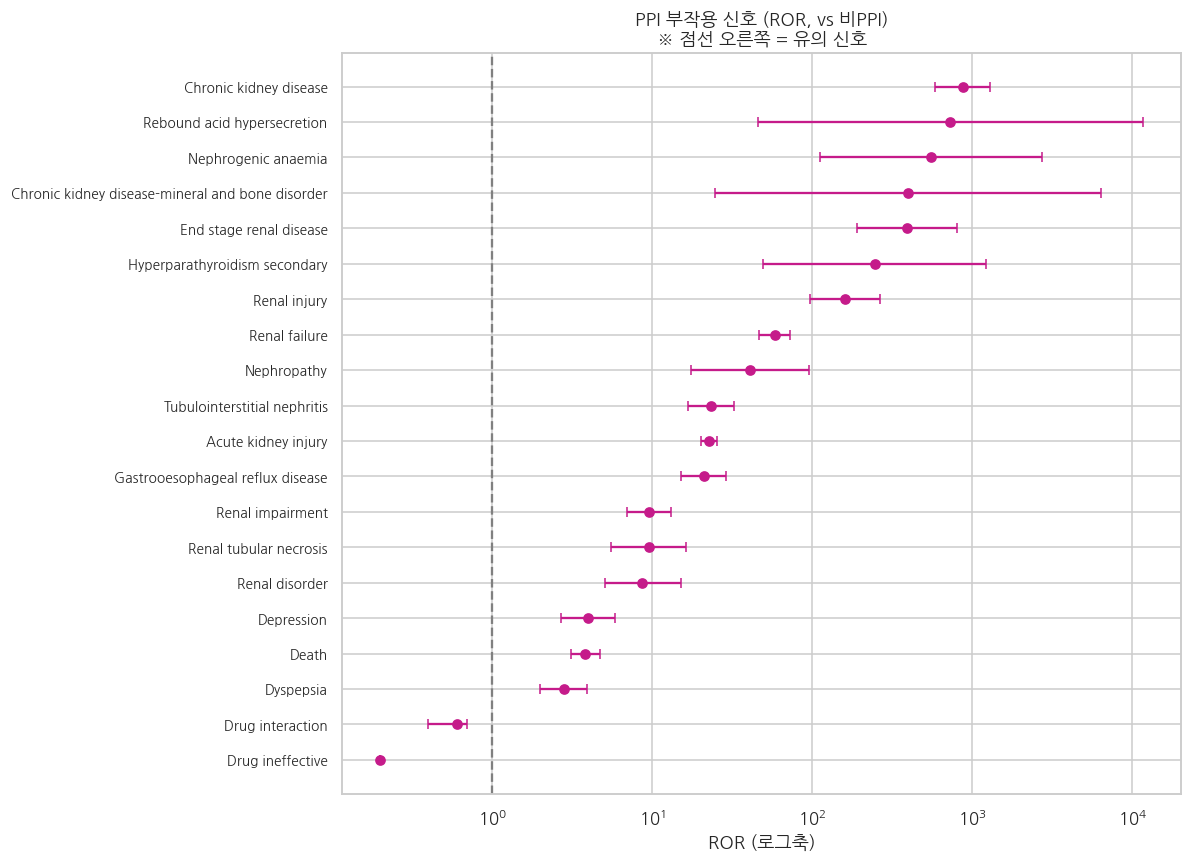

In [32]:
# PPI 부작용 신호 forest plot (ROR, vs 비PPI)
r = ror_df.sort_values('ROR')
fig, ax = plt.subplots(figsize=(11, 8))
y = range(len(r))
ax.errorbar(r['ROR'], y, xerr=[r['ROR']-r['95%CI下'], r['95%CI上']-r['ROR']],
            fmt='o', color='#c51b8a', capsize=3, ms=6)
ax.set_yticks(list(y)); ax.set_yticklabels(r['부작용'], fontsize=9)
ax.axvline(1, color='gray', ls='--')
ax.set_xscale('log')
ax.set_title('PPI 부작용 신호 (ROR, vs 비PPI)\n※ 점선 오른쪽 = 유의 신호', fontweight='bold')
ax.set_xlabel('ROR (로그축)')
plt.tight_layout(); plt.show()

=== [Acute kidney injury] 하위그룹별 ROR ===
 그룹  PPI건수  ROR  CI下  CI上
 여성   1791 26.2 21.8 31.5
 남성   1365 15.2 12.8 18.0
 청년    198 21.0 14.2 31.0
 중년   1810 26.4 21.1 33.0
 노년    578 11.0  8.8 13.8
초고령     75  5.4  3.7  8.0


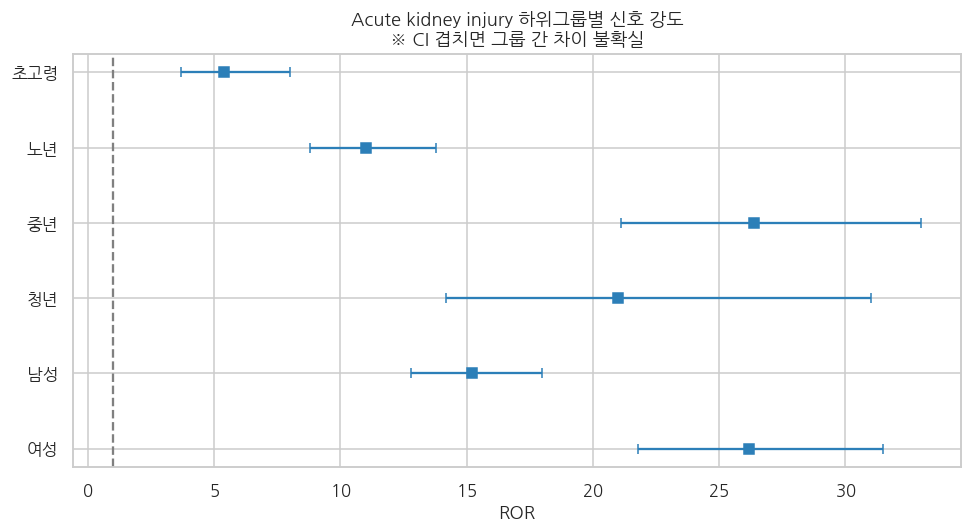

In [33]:
# 하위그룹(성별/연령대)별 ROR - 관심 부작용(급성신손상) 예시
background['sex'] = background['patient_sex'].where(background['patient_sex'].isin(['Male','Female']), 'Unknown')
background['age_num'] = pd.to_numeric(background['patient_age_years'], errors='coerce')
background['age_band'] = background['age_num'].apply(age_band)

def subgroup_ror(target_pt, group_col, group_val):
    """특정 부작용에 대해 (하위그룹 PPI) vs (같은 하위그룹 배경) ROR"""
    ps = ppi[ppi[group_col] == group_val]
    bs = background[background[group_col] == group_val]
    a = explode_reactions(ps).query("reaction_list == @target_pt")['report_id'].nunique()
    c = explode_reactions(bs).query("reaction_list == @target_pt")['report_id'].nunique()
    return compute_ror(a, ps['report_id'].nunique(), c, bs['report_id'].nunique()), a

TARGET = 'Acute kidney injury'
groups = [('sex','Female','여성'), ('sex','Male','남성'),
          ('age_band','청년(19-40)','청년'), ('age_band','중년(41-65)','중년'),
          ('age_band','노년(66-80)','노년'), ('age_band','초고령(81+)','초고령')]

sg = []
for col, val, label in groups:
    (ror, lo, hi, prr), a = subgroup_ror(TARGET, col, val)
    sg.append({'그룹':label, 'PPI건수':a, 'ROR':round(ror,1), 'CI下':round(lo,1), 'CI上':round(hi,1)})
sg_df = pd.DataFrame(sg)
print(f'=== [{TARGET}] 하위그룹별 ROR ===')
print(sg_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 5))
y = range(len(sg_df))
ax.errorbar(sg_df['ROR'], y, xerr=[sg_df['ROR']-sg_df['CI下'], sg_df['CI上']-sg_df['ROR']],
            fmt='s', color='#2c7fb8', capsize=3, ms=7)
ax.set_yticks(list(y)); ax.set_yticklabels(sg_df['그룹'])
ax.axvline(1, color='gray', ls='--')
ax.set_title(f'{TARGET} 하위그룹별 신호 강도\n※ CI 겹치면 그룹 간 차이 불확실', fontweight='bold')
ax.set_xlabel('ROR')
plt.tight_layout(); plt.show()

In [34]:
# 연령대/성별 x 장기계통 카이제곱 + FDR 보정
from scipy import stats

case_organ = reac.groupby('report_id')['organ'].apply(set)
ppi_c = ppi.set_index('report_id').copy()
ppi_c['organs'] = case_organ
top_organ = reac['organ'].value_counts().head(8).index.tolist()

def chisq_fdr(sub, group_col):
    """group_col(성별/연령대 등) x 각 장기계통 교차표에 카이제곱 + FDR 보정"""
    rows = []
    for o in top_organ:
        flag = sub['organs'].apply(lambda s: o in s if isinstance(s, set) else False)
        tab = pd.crosstab(sub[group_col], flag)
        if tab.shape[1] == 2:
            chi2, p, _, _ = stats.chi2_contingency(tab)
            rows.append({'장기계통': o, 'p_raw': p})
    out = pd.DataFrame(rows)
    out['p_adj(FDR)'] = multipletests(out['p_raw'], method='fdr_bh')[1]
    out['유의'] = np.where(out['p_adj(FDR)'] < 0.05, 'O', '')
    return out

print('=== 연령대 x 장기계통 ===')
age_res = chisq_fdr(ppi_c[ppi_c['age_band']!='Unknown'], 'age_band')
print(age_res.to_string(index=False))

print('\n=== 성별 x 장기계통 ===')
sex_res = chisq_fdr(ppi_c[ppi_c['sex'].isin(['Male','Female'])], 'sex')
print(sex_res.to_string(index=False))

=== 연령대 x 장기계통 ===
    장기계통        p_raw   p_adj(FDR) 유의
   신장/비뇨 1.120419e-61 8.963352e-61  O
기타(일반증상) 7.707075e-57 3.082830e-56  O
     소화기 1.739961e-02 1.739961e-02  O
   뼈/전해질 1.359617e-04 1.553848e-04  O
 약물사용/오류 5.020658e-29 1.338842e-28  O
     호흡기 6.188419e-09 1.237684e-08  O
     심혈관 2.674471e-07 4.279153e-07  O
   피부/과민 5.308622e-05 7.078162e-05  O

=== 성별 x 장기계통 ===
    장기계통    p_raw  p_adj(FDR) 유의
   신장/비뇨 0.076291    0.141019   
기타(일반증상) 0.989328    0.989328   
     소화기 0.071832    0.141019   
   뼈/전해질 0.323736    0.431648   
 약물사용/오류 0.088137    0.141019   
     호흡기 0.468324    0.535228   
     심혈관 0.007374    0.058990   
   피부/과민 0.015990    0.063959   


In [35]:
# 사망 예측요인: 범주형(카이제곱) + 연속형(t검정)
for col, label in [('age_band','연령대'), ('sex','성별'), ('ingredient','성분')]:
    sub = ppi_c[ppi_c[col] != 'Unknown'] if col != 'ingredient' else ppi_c
    tab = pd.crosstab(sub[col], sub['is_fatal'])
    chi2, p, _, _ = stats.chi2_contingency(tab)
    sig = '유의' if p < 0.05 else '비유의'
    print(f'{label:6s} -> 사망 : chi2={chi2:.1f}, p={p:.2e}  {sig}')

dead  = ppi_c[ppi_c['is_fatal']]['age_num'].dropna()
alive = ppi_c[~ppi_c['is_fatal']]['age_num'].dropna()
t, p = stats.ttest_ind(dead, alive, equal_var=False)
print(f'\n사망군 평균연령 {dead.mean():.1f}세 vs 생존군 {alive.mean():.1f}세 : t={t:.1f}, p={p:.2e}')

연령대    -> 사망 : chi2=98.1, p=2.45e-20  유의
성별     -> 사망 : chi2=19.3, p=1.14e-05  유의
성분     -> 사망 : chi2=19.1, p=2.62e-04  유의

사망군 평균연령 62.2세 vs 생존군 57.7세 : t=8.2, p=7.19e-16


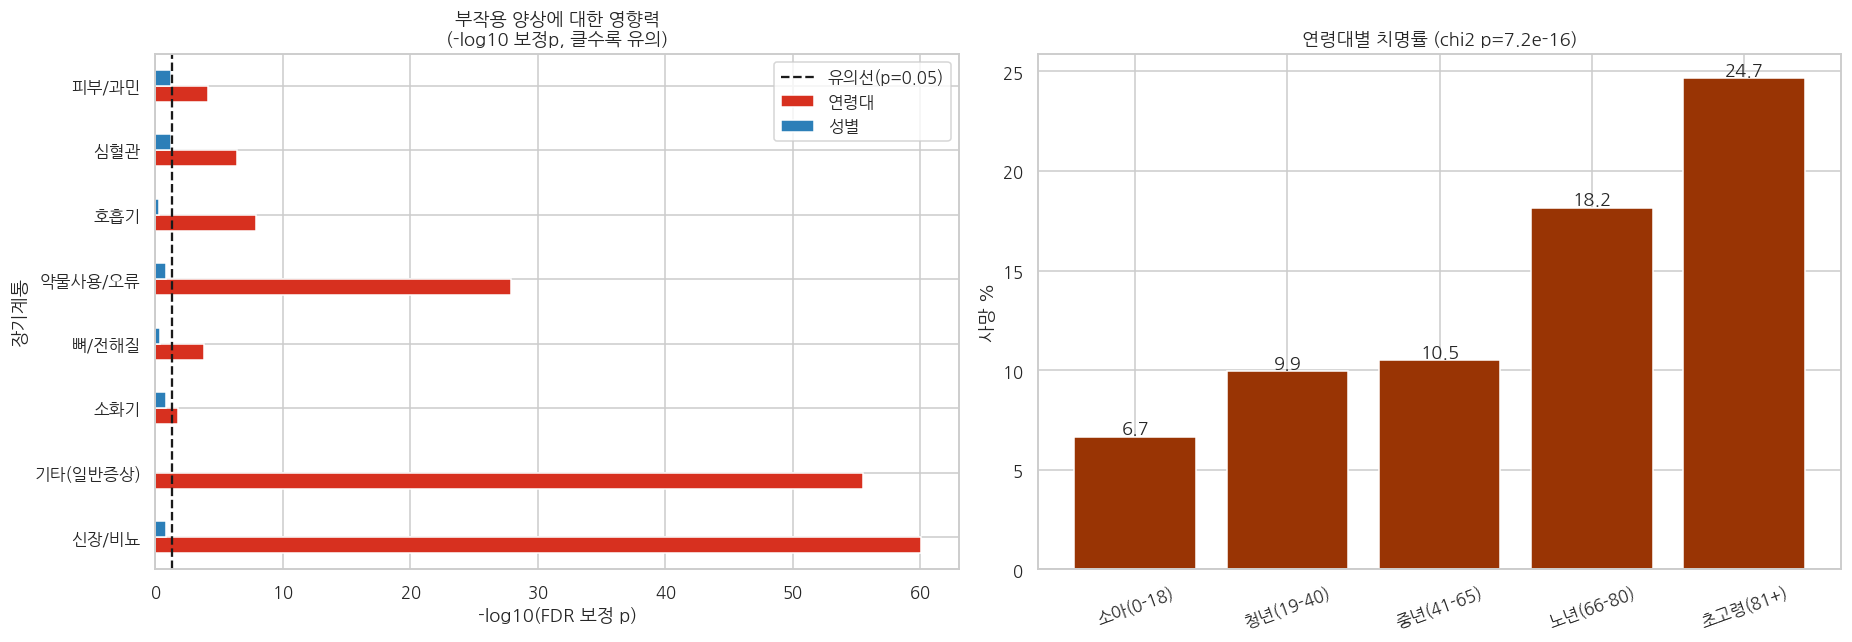

In [36]:
# 부작용 양상에 대한 영향력(-log10 보정p) + 연령대별 치명률
fig, ax = plt.subplots(1, 2, figsize=(17, 6))

comp = pd.DataFrame({
    '연령대': -np.log10(age_res.set_index('장기계통')['p_adj(FDR)']),
    '성별':  -np.log10(sex_res.set_index('장기계통')['p_adj(FDR)']),
})
comp.plot(kind='barh', ax=ax[0], color=['#d7301f','#2c7fb8'])
ax[0].axvline(-np.log10(0.05), color='k', ls='--', label='유의선(p=0.05)')
ax[0].set_title('부작용 양상에 대한 영향력\n(-log10 보정p, 클수록 유의)', fontweight='bold')
ax[0].set_xlabel('-log10(FDR 보정 p)'); ax[0].legend()

order = ['소아(0-18)','청년(19-40)','중년(41-65)','노년(66-80)','초고령(81+)']
fa = (ppi_c[ppi_c['age_band']!='Unknown'].groupby('age_band')['is_fatal'].mean()*100).reindex(order)
ax[1].bar(range(len(fa)), fa.values, color='#993404')
ax[1].set_xticks(range(len(fa))); ax[1].set_xticklabels(fa.index, rotation=20)
ax[1].set_title(f'연령대별 치명률 (chi2 p={p:.1e})', fontweight='bold'); ax[1].set_ylabel('사망 %')
for i, v in enumerate(fa.values): ax[1].text(i, v, f'{v:.1f}', ha='center', va='bottom')

plt.tight_layout(); plt.show()